# Tech Challenge — Classificação da Qualidade de Vinhos com Machine Learning
**POSTECH FIAP — Data Analytics — Fase 2**

## 1. Compreensão do Problema

A indústria vitivinícola avalia a qualidade do vinho tradicionalmente por meio de análise sensorial de especialistas — um processo subjetivo, caro e demorado. Este trabalho usa dados físico-químicos (o **Wine Quality Dataset**, variante *red* do "Vinho Verde" português, disponibilizado no Kaggle/UCI) para treinar modelos que prevejam a qualidade do vinho, apoiando a padronização do processo produtivo.

**Variável alvo:** a coluna original `quality` (nota de especialistas, 0–10) foi transformada em uma classificação binária:
- **Alta Qualidade**: `quality >= 7`
- **Baixa/Média Qualidade**: `quality < 7`

> **Nota de hipótese:** o enunciado cita "Wine Quality Dataset" sem especificar a variante. Foi usado o dataset de **vinho tinto (red)**, com 1.599 amostras — a versão mais comum de referência (Cortez et al., 2009). Se o grupo precisar incluir também o vinho branco, o mesmo pipeline se aplica bastando concatenar `winequality-white.csv` com uma coluna `type`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 2. Carga dos Dados

In [2]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 3. Transformação da Variável Alvo

In [4]:
df["quality_label"] = np.where(df["quality"] >= 7, "Alta Qualidade", "Baixa/Média Qualidade")
df["target"] = (df["quality"] >= 7).astype(int)

df[["quality", "quality_label", "target"]].sample(5, random_state=1)

,quality,quality_label,target
75,5,Baixa/Média Qualidade,0
1283,6,Baixa/Média Qualidade,0
408,6,Baixa/Média Qualidade,0
1281,6,Baixa/Média Qualidade,0
1118,6,Baixa/Média Qualidade,0


## 4. Análise Exploratória de Dados (EDA)

### 4.1 Qualidade dos dados: nulos e duplicadas

In [5]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()} ({df.duplicated().mean()*100:.1f}%)")

Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
target                  0
dtype: int64

Linhas duplicadas: 240 (15.0%)


Não há valores nulos. Há, porém, um número relevante de linhas duplicadas — comum neste dataset público, já que ele contém apenas variáveis físico-químicas arredondadas e amostras diferentes podem coincidir exatamente. Essas duplicadas serão removidas na etapa de pré-processamento para não enviesar o treino (o mesmo padrão sendo aprendido várias vezes) nem vazar exemplos idênticos entre treino e teste.

### 4.2 Estatísticas descritivas

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### 4.3 Distribuição da variável `quality` original

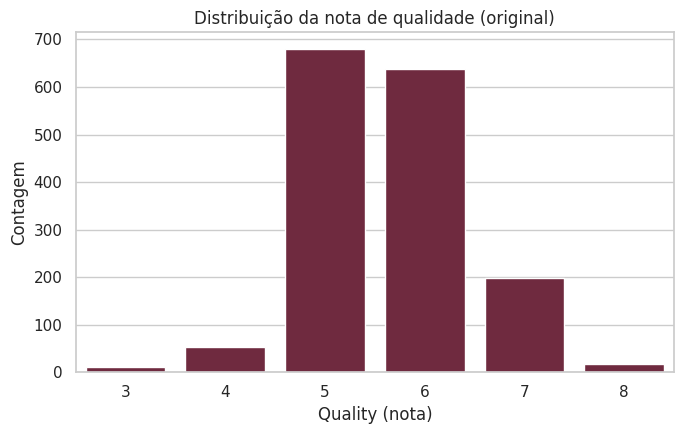

In [7]:
plt.figure(figsize=(7,4.5))
sns.countplot(x="quality", data=df, color="#7b1e3a")
plt.title("Distribuição da nota de qualidade (original)")
plt.xlabel("Quality (nota)")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

A distribuição da nota original é aproximadamente normal, concentrada nas notas 5 e 6 (vinhos medianos). Notas extremas (3, 4, 8) são raras — o que já antecipa o desbalanceamento da versão binária.

### 4.4 Balanceamento das classes (target binário)

quality_label
Baixa/Média Qualidade    1382
Alta Qualidade            217
Name: count, dtype: int64
quality_label
Baixa/Média Qualidade    86.43
Alta Qualidade           13.57
Name: proportion, dtype: float64


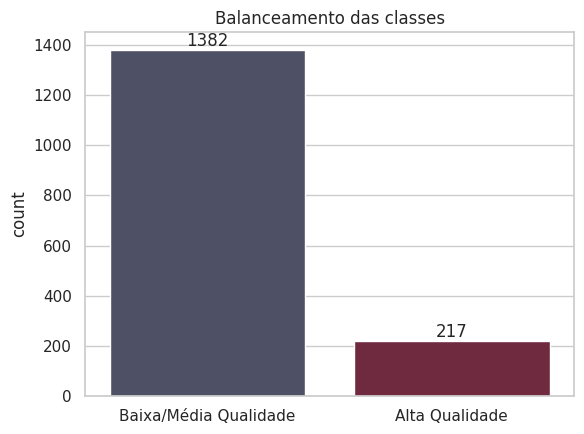

In [8]:
order = ["Baixa/Média Qualidade", "Alta Qualidade"]
counts = df["quality_label"].value_counts()
pct = df["quality_label"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

plt.figure(figsize=(6,4.5))
ax = sns.countplot(x="quality_label", data=df, order=order, hue="quality_label", palette=["#4a4e69", "#7b1e3a"], legend=False)
plt.title("Balanceamento das classes")
plt.xlabel("")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Classes fortemente desbalanceadas: ~86% Baixa/Média vs. ~14% Alta Qualidade.** Isso tem duas implicações práticas para as próximas etapas:
1. **Acurácia sozinha não é uma métrica confiável** — um modelo "preguiçoso" que sempre prevê "Baixa/Média" já acertaria ~86%. Por isso o foco de avaliação será em **precisão, recall, F1 e ROC-AUC** da classe Alta Qualidade.
2. Será aplicado **SMOTE** (oversampling sintético) no conjunto de treino para balancear as classes antes do ajuste dos modelos.


### 4.5 Correlação entre variáveis e com o alvo

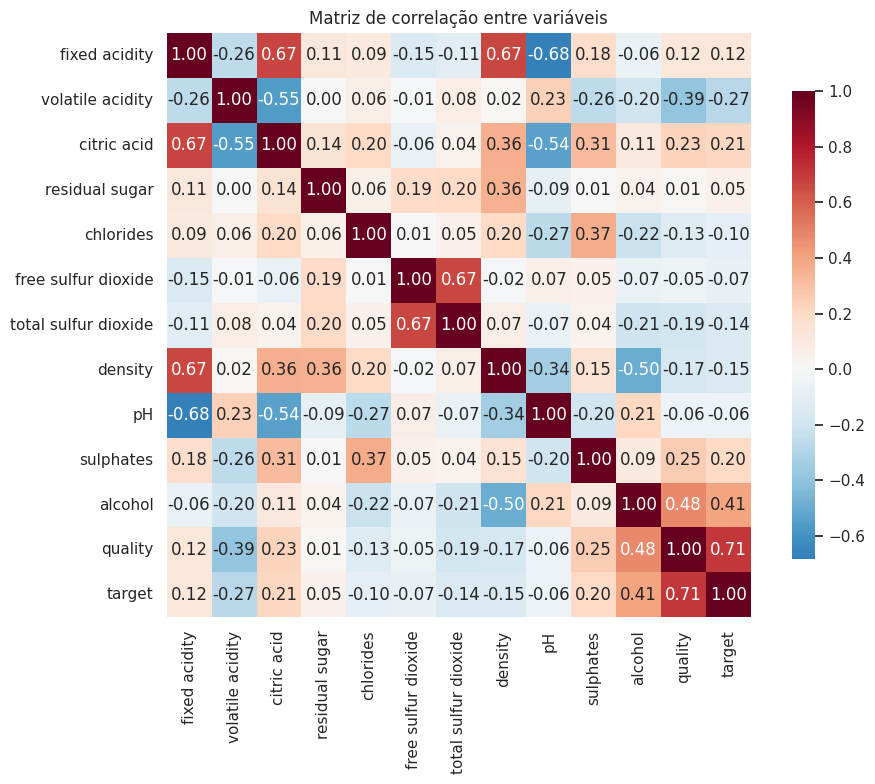

In [9]:
corr_matrix = df.drop(columns=["quality_label"]).corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.8})
plt.title("Matriz de correlação entre variáveis")
plt.tight_layout()
plt.show()

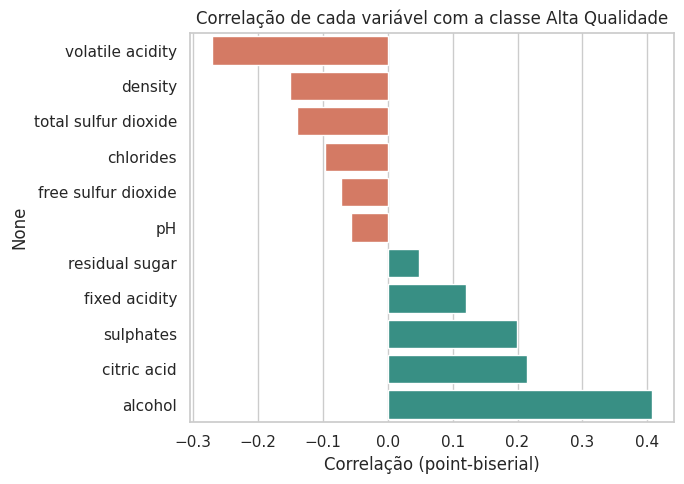

alcohol                 0.407315
citric acid             0.214716
sulphates               0.199485
fixed acidity           0.120061
residual sugar          0.047779
pH                     -0.057283
free sulfur dioxide    -0.071747
chlorides              -0.097308
total sulfur dioxide   -0.139517
density                -0.150460
volatile acidity       -0.270712
Name: target, dtype: float64

In [10]:
corr_target = corr_matrix["target"].drop(["target", "quality"]).sort_values()
plt.figure(figsize=(7,5))
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=colors, legend=False)
plt.title("Correlação de cada variável com a classe Alta Qualidade")
plt.xlabel("Correlação (point-biserial)")
plt.tight_layout()
plt.show()

corr_target.sort_values(ascending=False)

**Leitura das correlações mais fortes com a classe Alta Qualidade:**
- **`alcohol` (+0.41)**: teor alcoólico é o preditor positivo mais forte — vinhos com mais álcool tendem a ser mais bem avaliados, geralmente associados a uvas mais maduras/melhor fermentação.
- **`volatile acidity` (-0.27)**: acidez volátil (ácido acético, relacionado a defeitos de fermentação/avinagramento) é o preditor negativo mais forte — quanto maior, pior a nota.
- **`sulphates` (+0.20)** e **`citric acid` (+0.21)**: sulfatos (antioxidante/antimicrobiano) e ácido cítrico (frescor) têm correlação positiva moderada.
- **`density` (-0.15)** e **`total sulfur dioxide` (-0.14)**: correlações negativas mais fracas, mas coerentes — densidade mais alta costuma indicar mais açúcar residual/menos álcool.
- Variáveis como `residual sugar`, `pH` e `free sulfur dioxide` têm correlação muito fraca com o alvo, isoladamente.

Nenhuma variável apresenta multicolinearidade extrema (>0.9) com outra, exceto `fixed acidity` x `pH`/`citric acid` (correlação moderada esperada, pois todas descrevem acidez) — não há necessidade de remover variáveis por colinearidade.

### 4.6 Distribuição das variáveis mais relevantes por classe

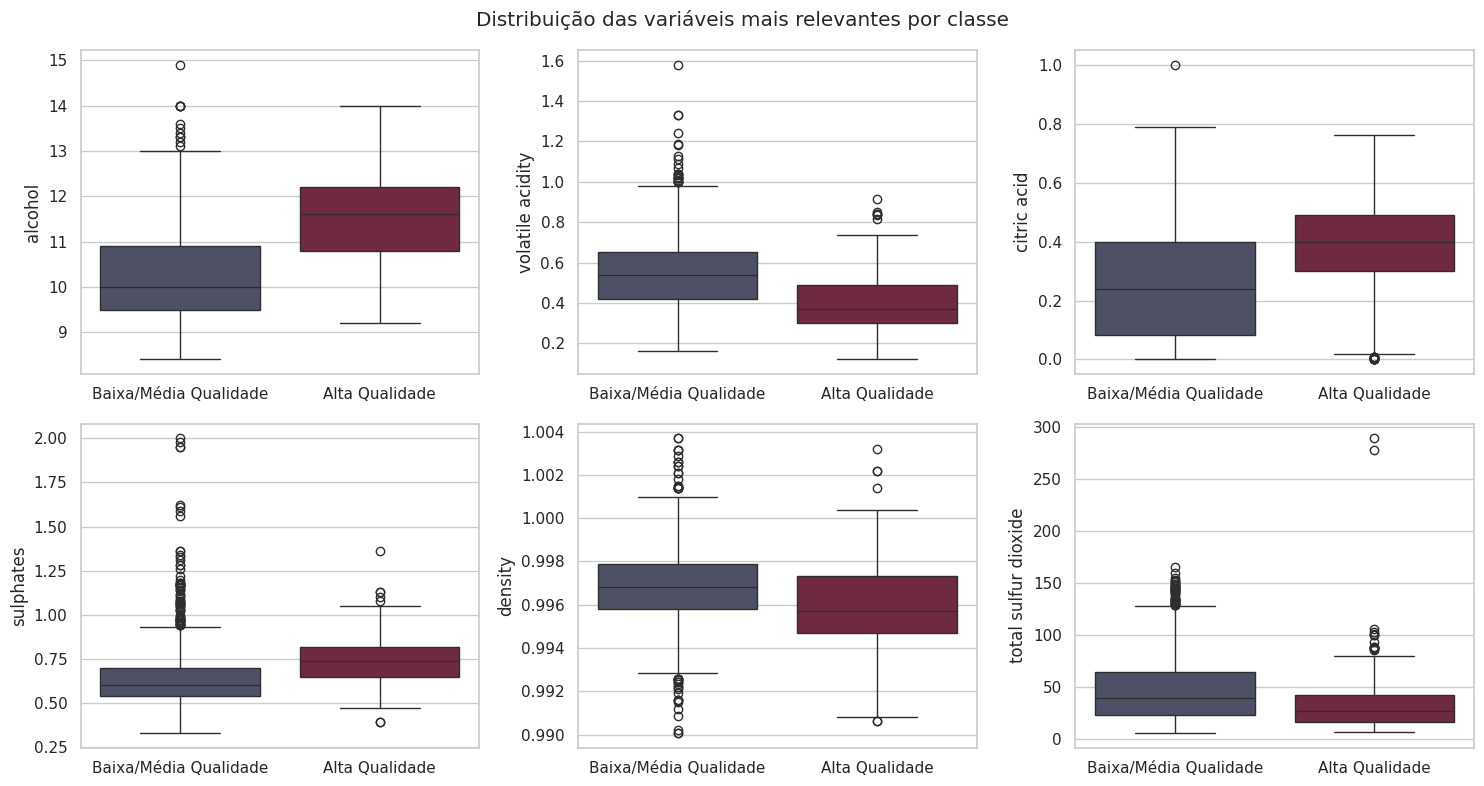

In [11]:
top_vars = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, top_vars):
    sns.boxplot(x="quality_label", y=var, data=df, order=order, hue="quality_label", ax=ax, palette=["#4a4e69", "#7b1e3a"], legend=False)
    ax.set_xlabel("")
plt.suptitle("Distribuição das variáveis mais relevantes por classe")
plt.tight_layout()
plt.show()

### 4.7 Outliers (regra IQR 1.5×)

In [12]:
outlier_summary = {}
for col in df.select_dtypes(include=[np.number]).columns:
    if col in ["quality", "target"]:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_out

pd.Series(outlier_summary).sort_values(ascending=False)

residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1
dtype: int64

`residual sugar` (9,7%) e `chlorides` (7,0%) são as variáveis com mais outliers pela regra do IQR. São valores fisicamente plausíveis (não são erros de digitação — os máximos batem com o range documentado do dataset original), então a decisão foi **não removê-los**, e sim usar modelos robustos a outliers (Random Forest, Gradient Boosting) e padronização (para a Regressão Logística) em vez de winsorização, evitando perda de informação sobre vinhos atípicos que podem ser justamente os de nota mais extrema.

## 5. Pré-processamento de Dados

In [13]:
# Remover duplicadas (baseado em todas as colunas originais, exceto o rótulo textual)
n_dup = df.drop(columns=["quality_label"]).duplicated().sum()
df_clean = df.drop_duplicates(subset=[c for c in df.columns if c != "quality_label"]).reset_index(drop=True)
print(f"Duplicadas removidas: {n_dup} | shape final: {df_clean.shape}")

Duplicadas removidas: 240 | shape final: (1359, 14)


### 5.1 Feature engineering

Duas variáveis derivadas foram criadas, com justificativa enológica:
- **`free_total_so2_ratio`**: razão entre SO2 livre e SO2 total — indica a fração do conservante ainda "ativa" (o SO2 combinado já reagiu e perdeu efeito protetor).
- **`acidity_ratio`**: razão entre acidez fixa e volátil — combina em uma única feature o efeito "acidez estrutural boa" vs. "acidez de defeito", que a EDA mostrou terem efeitos opostos no target.

In [14]:
df_clean["free_total_so2_ratio"] = df_clean["free sulfur dioxide"] / df_clean["total sulfur dioxide"]
df_clean["acidity_ratio"] = df_clean["fixed acidity"] / (df_clean["volatile acidity"] + 1e-6)

feature_cols = [c for c in df_clean.columns if c not in ["quality", "quality_label", "target"]]
X = df_clean[feature_cols]
y = df_clean["target"]
print(f"{len(feature_cols)} features:", feature_cols)

13 features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'free_total_so2_ratio', 'acidity_ratio']


### 5.2 Split treino/teste (estratificado)

Não há dados faltantes a tratar. O split é feito **antes** da padronização e do SMOTE, para evitar vazamento de dados (data leakage) do teste para o treino.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporção Alta Qualidade — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: (1087, 13) | Teste: (272, 13)
Proporção Alta Qualidade — treino: 0.135 | teste: 0.136


### 5.3 Padronização (StandardScaler)

Necessária para a Regressão Logística (sensível à escala das variáveis); não prejudica os modelos baseados em árvore.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5.4 Balanceamento de classes (SMOTE)

Aplicado **apenas no conjunto de treino** (o teste permanece com a distribuição real, para uma avaliação honesta).

In [17]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print("Distribuição pós-SMOTE (treino):", np.bincount(y_train_bal))

Distribuição pós-SMOTE (treino): [940 940]


## 6. Desenvolvimento de Modelos

Foram treinados três classificadores, todos sobre o mesmo conjunto de treino balanceado:
1. **Regressão Logística** — baseline linear, interpretável.
2. **Random Forest** — ensemble não-linear, robusto a outliers e relações não-lineares.
3. **Gradient Boosting** — ensemble sequencial, geralmente com melhor poder preditivo em datasets tabulares pequenos/médios.

In [18]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
roc_data = {}
cm_data = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    cv_scores = cross_val_score(
        model, X_train_bal, y_train_bal,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="f1"
    )

    results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "f1_cv_mean": cv_scores.mean(),
        "f1_cv_std": cv_scores.std(),
    })
    roc_data[name] = roc_curve(y_test, y_proba)
    cm_data[name] = confusion_matrix(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Baixa/Média", "Alta Qualidade"]))


=== Regressão Logística ===
                precision    recall  f1-score   support

   Baixa/Média       0.97      0.76      0.85       235
Alta Qualidade       0.35      0.84      0.50        37

      accuracy                           0.77       272
     macro avg       0.66      0.80      0.67       272
  weighted avg       0.88      0.77      0.80       272




=== Random Forest ===
                precision    recall  f1-score   support

   Baixa/Média       0.93      0.91      0.92       235
Alta Qualidade       0.49      0.54      0.51        37

      accuracy                           0.86       272
     macro avg       0.71      0.73      0.72       272
  weighted avg       0.87      0.86      0.86       272




=== Gradient Boosting ===
                precision    recall  f1-score   support

   Baixa/Média       0.95      0.87      0.91       235
Alta Qualidade       0.47      0.73      0.57        37

      accuracy                           0.85       272
     macro avg       0.71      0.80      0.74       272
  weighted avg       0.89      0.85      0.86       272



## 7. Avaliação dos Modelos

In [19]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df.round(4)

,modelo,accuracy,precision,recall,f1,roc_auc,f1_cv_mean,f1_cv_std
2,Gradient Boosting,0.8493,0.4655,0.7297,0.5684,0.8855,0.8976,0.0088
1,Random Forest,0.8603,0.4878,0.5405,0.5128,0.8787,0.9334,0.0112
0,Regressão Logística,0.7684,0.3523,0.8378,0.4960,0.8926,0.8237,0.0251


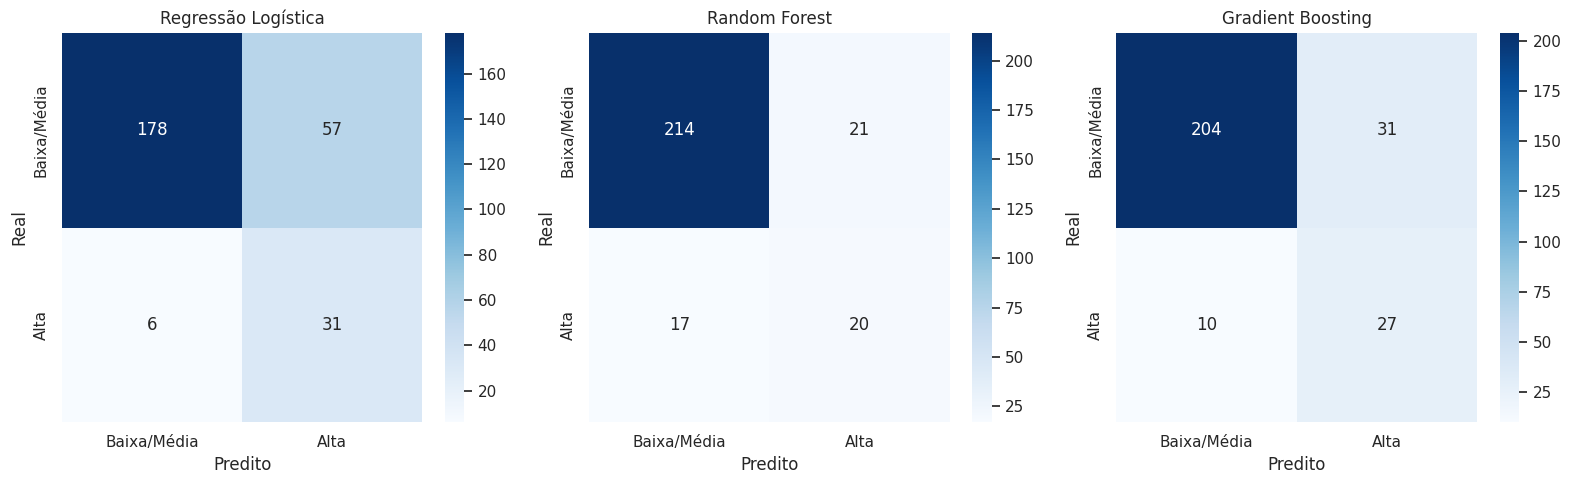

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, cm) in zip(axes, cm_data.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Baixa/Média", "Alta"], yticklabels=["Baixa/Média", "Alta"])
    ax.set_title(name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

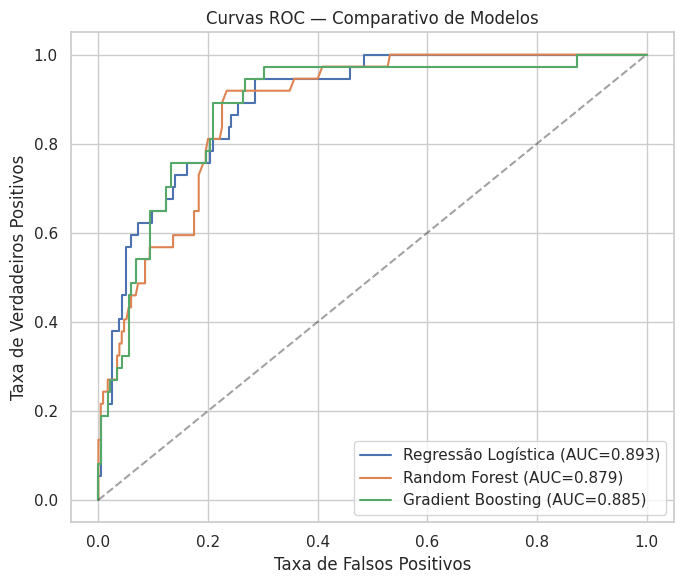

In [21]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _) in roc_data.items():
    auc_val = results_df.loc[results_df["modelo"] == name, "roc_auc"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curvas ROC — Comparativo de Modelos")
plt.legend()
plt.tight_layout()
plt.show()

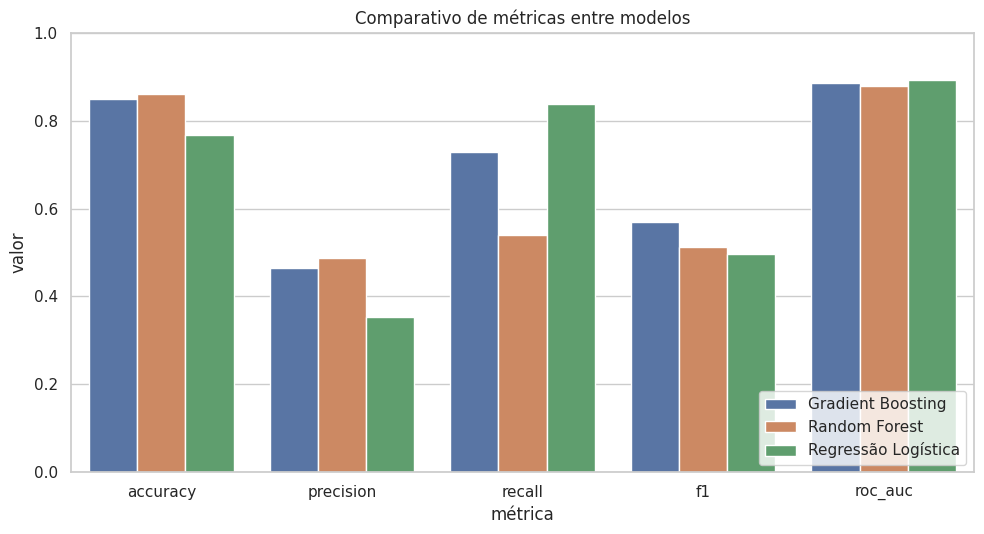

In [22]:
metrics_melt = results_df.melt(id_vars="modelo", value_vars=["accuracy","precision","recall","f1","roc_auc"],
                                  var_name="métrica", value_name="valor")
plt.figure(figsize=(10, 5.5))
sns.barplot(data=metrics_melt, x="métrica", y="valor", hue="modelo")
plt.ylim(0, 1)
plt.title("Comparativo de métricas entre modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 7.1 Comparação entre os modelos

- **Random Forest** tem a maior acurácia geral (86%) e a maior precisão para Alta Qualidade (49%), mas o menor recall (54%) — ou seja, é mais "conservador": quando aponta um vinho como Alta Qualidade, costuma acertar, mas deixa passar mais vinhos bons classificando-os como medianos.
- **Gradient Boosting** tem o melhor equilíbrio entre precisão e recall (F1 = 0,57, o melhor do grupo) e o maior recall entre os ensembles (73%) — captura mais vinhos de alta qualidade, com uma perda controlada de precisão.
- **Regressão Logística** tem o maior recall (84%) mas a menor precisão (35%) — sinaliza "Alta Qualidade" com frequência, inclusive para vinhos que não são, o que a torna útil como triagem inicial (não perder nenhum vinho bom) mas não como decisão final.
- Em **ROC-AUC**, os três modelos ficam próximos (0,88–0,89), indicando que todos discriminam razoavelmente bem as classes — a diferença prática está em **onde** se coloca o limiar de decisão.

**Recomendação de negócio:** se o custo de "perder" um vinho de alta qualidade (falso negativo) for maior que o custo de investigar um vinho mediano classificado como bom (falso positivo) — cenário típico em triagem de produção — o **Gradient Boosting** é o modelo mais equilibrado para uso prático; a **Regressão Logística** pode servir como filtro inicial de alta sensibilidade.

## 8. Interpretação dos Resultados

/tmp/ipykernel_565/3004234791.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#7b1e3a'` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, hue=importances.index, color="#7b1e3a", legend=False)


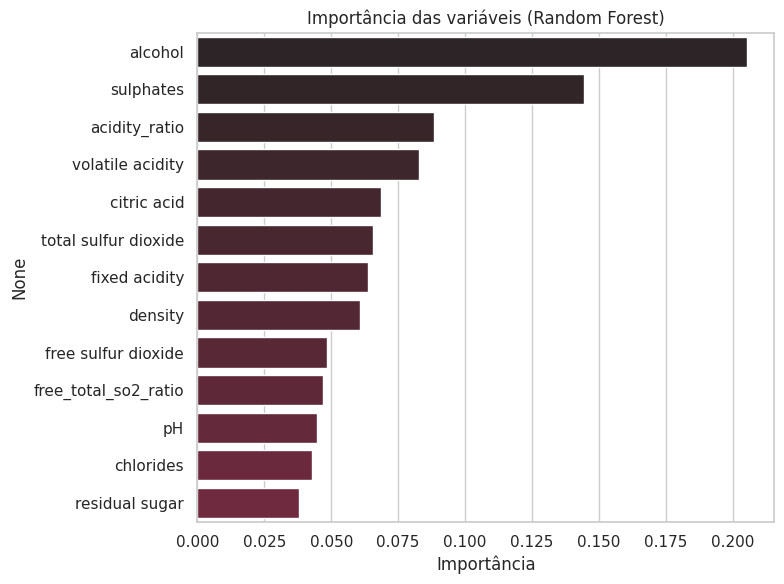

alcohol                 0.205122
sulphates               0.144396
acidity_ratio           0.088234
volatile acidity        0.082729
citric acid             0.068472
total sulfur dioxide    0.065529
fixed acidity           0.063865
density                 0.060905
free sulfur dioxide     0.048236
free_total_so2_ratio    0.046971
pH                      0.044627
chlorides               0.042957
residual sugar          0.037956
dtype: float64

In [23]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, color="#7b1e3a", legend=False)
plt.title("Importância das variáveis (Random Forest)")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

importances

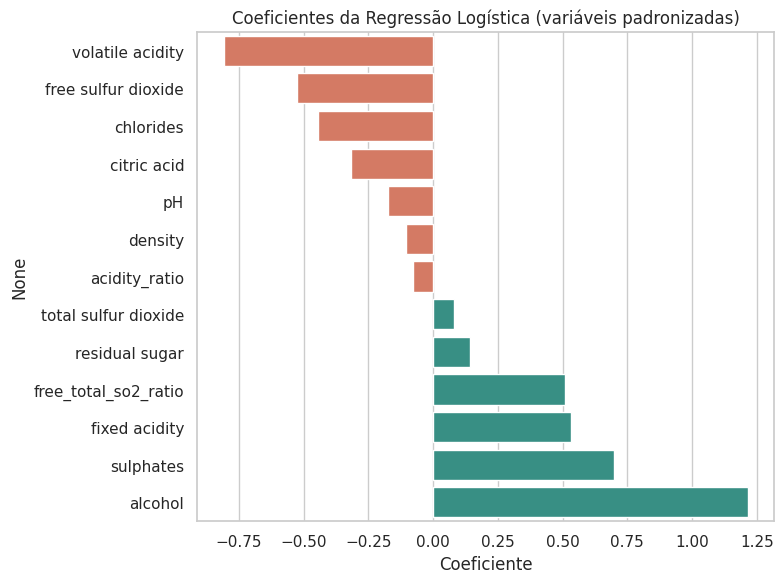

alcohol                 1.215316
sulphates               0.696793
fixed acidity           0.530762
free_total_so2_ratio    0.508160
residual sugar          0.140871
total sulfur dioxide    0.079959
acidity_ratio          -0.077058
density                -0.103989
pH                     -0.175998
citric acid            -0.315886
chlorides              -0.445463
free sulfur dioxide    -0.526595
volatile acidity       -0.809064
dtype: float64

In [24]:
logit_model = models["Regressão Logística"]
coefs = pd.Series(logit_model.coef_[0], index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
colors = ["#e76f51" if v < 0 else "#2a9d8f" for v in coefs.values]
sns.barplot(x=coefs.values, y=coefs.index, hue=coefs.index, palette=colors, legend=False)
plt.title("Coeficientes da Regressão Logística (variáveis padronizadas)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)

### 8.1 Variáveis com maior influência na qualidade

Random Forest e Regressão Logística convergem no mesmo top-3:

1. **`alcohol` (teor alcoólico)** — a variável mais importante em ambos os modelos. Vinhos com maior teor alcoólico são consistentemente associados à classe Alta Qualidade.
2. **`sulphates` (sulfatos)** — segunda variável mais relevante; atua como conservante/antioxidante e está associada a vinhos mais estáveis e bem avaliados.
3. **`volatile acidity` (acidez volátil)** — principal variável com efeito **negativo**: quanto maior, pior a qualidade percebida (associada a defeitos de fermentação/avinagramento).
4. **`acidity_ratio`** (feature derivada) confirma seu valor: aparece entre as mais importantes, validando a hipótese de que o equilíbrio entre acidez "boa" (fixa) e "de defeito" (volátil) é mais informativo que as variáveis isoladas.
5. **`citric acid`** — contribui positivamente, reforçando o papel do frescor/equilíbrio ácido.

### 8.2 Implicações para o processo de produção

- **Controle de teor alcoólico**: monitorar o ponto de colheita/fermentação para atingir teores alcoólicos mais altos (dentro do estilo do vinho) pode ser uma alavanca direta de qualidade percebida.
- **Gestão da acidez volátil**: como é o principal fator negativo, processos de controle de contaminação bacteriana e temperatura de fermentação (que geram ácido acético) merecem atenção prioritária no controle de qualidade.
- **Dosagem de sulfatos**: dentro dos limites regulatórios/sensoriais, ajustar a dosagem de sulfatos pode contribuir para maior estabilidade e nota de qualidade.
- **Uso do modelo como triagem, não substituto do enólogo**: dado que a classe "Alta Qualidade" é rara (~14%) e as métricas de precisão para essa classe ainda são moderadas (35–49%), o modelo é mais indicado como uma **ferramenta de priorização** (quais lotes merecem avaliação sensorial mais aprofundada) do que como decisão automática final.

## 9. Conclusão

O desafio foi resolvido de ponta a ponta: da compreensão do problema à interpretação dos resultados. O **Gradient Boosting** apresentou o melhor equilíbrio entre as métricas (F1 = 0,57, ROC-AUC = 0,89), sendo o modelo recomendado para uso prático, com o teor alcoólico, os sulfatos e a acidez volátil como principais variáveis explicativas — achados consistentes com o conhecimento enológico de domínio, o que reforça a confiabilidade do modelo.